In [9]:
#ZARA DATASET

# IMPORTAR LIBRERIAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.filterwarnings('ignore')
# Configuració estètica
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from scipy.stats import spearmanr, pearsonr, shapiro
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import shapiro
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import numpy as np
# Configuración de estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Librerías importadas correctamente")


# Si el archivo usa otro separador como punto y coma
df = pd.read_csv(
    r"C:\Users\Lucan Vieira\Documents\GitHub\Proyectos\MARKETING\Data\Amazon_bestsellers_items_2025.csv",
    sep=',',  # o el delimitador que corresponda
    engine='python'
)

# Mostrar las primeras filas para verificar
print(df.head())

print("Tipos de datos por columna:")
print(df.dtypes) 
# Información detallada
print("\nInformación completa del dataset:")
print(df.info())

# Estadísticas descriptivas por tipo de dato
print("\nResumen de datos numéricos:")
print(df.describe())

print("\nFirst 5 rows:")
df.head()


✅ Librerías importadas correctamente
   Unnamed: 0  rank        asin  \
0           0     1  B073VKKNN9   
1           1     2  B07PQZJ6Y8   
2           2     3  B0D1KL34JM   
3           3     4  B07B9YYLGG   
4           4     5  B073VLGMZ4   

                                       product_title product_price  \
0  Kaspersky | Premium - Total Security (Ultimate...       ₹469.00   
1  K7 Security K7, Total Security, 1 User, 1 Year...       ₹370.00   
2  Microsoft Office 2021 Professional - Lifetime ...     ₹1,799.00   
3  Bitdefender - 1 Device,1 Year - Mobile Securit...        ₹94.00   
4  McAfee Total Protection 2025 | 1 Device, 3 Yea...     ₹1,699.00   

   product_star_rating  product_num_ratings  \
0                  4.3              13324.0   
1                  4.4               2291.0   
2                  4.5                388.0   
3                  4.1               9630.0   
4                  4.4               5783.0   

                           product_url  \
0  htt

,Unnamed: 0,rank,asin,product_title,product_price,product_star_rating,product_num_ratings,product_url,product_photo,rank_change_label,country,page
0,0,1,B073VKKNN9,Kaspersky | Premium - Total Security (Ultimate...,₹469.00,4.3,13324.0,https://www.amazon.in/dp/B073VKKNN9,https://images-eu.ssl-images-amazon.com/images...,NaN,IN,1
1,1,2,B07PQZJ6Y8,"K7 Security K7, Total Security, 1 User, 1 Year...",₹370.00,4.4,2291.0,https://www.amazon.in/dp/B07PQZJ6Y8,https://images-eu.ssl-images-amazon.com/images...,NaN,IN,1
2,2,3,B0D1KL34JM,Microsoft Office 2021 Professional - Lifetime ...,"₹1,799.00",4.5,388.0,https://www.amazon.in/dp/B0D1KL34JM,https://images-eu.ssl-images-amazon.com/images...,NaN,IN,1
3,3,4,B07B9YYLGG,"Bitdefender - 1 Device,1 Year - Mobile Securit...",₹94.00,4.1,9630.0,https://www.amazon.in/dp/B07B9YYLGG,https://images-eu.ssl-images-amazon.com/images...,NaN,IN,1
4,4,5,B073VLGMZ4,"McAfee Total Protection 2025 | 1 Device, 3 Yea...","₹1,699.00",4.4,5783.0,https://www.amazon.in/dp/B073VLGMZ4,https://images-eu.ssl-images-amazon.com/images...,NaN,IN,1


In [10]:
def initial_data_assessment(df):
    """Comprehensive initial data assessment"""
    
    print("="*80)
    print("AMAZON DATASET INITIAL ASSESSMENT")
    print("="*80)
    
    # Basic info
    print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # Column info
    print("\n" + "="*80)
    print("COLUMN INFORMATION")
    print("="*80)
    
    column_info = []
    for col in df.columns:
        column_info.append({
            'Column': col,
            'Data Type': df[col].dtype,
            'Non-Null Count': df[col].count(),
            'Null Count': df[col].isnull().sum(),
            'Null %': f"{(df[col].isnull().sum() / len(df)) * 100:.2f}%",
            'Unique Values': df[col].nunique()
        })
    
    col_df = pd.DataFrame(column_info)
    print(col_df.to_string(index=False))
    
    return col_df

# Run initial assessment
col_info = initial_data_assessment(df)

AMAZON DATASET INITIAL ASSESSMENT

Dataset Shape: 999 rows × 12 columns
Memory Usage: 0.64 MB

COLUMN INFORMATION
             Column Data Type  Non-Null Count  Null Count  Null %  Unique Values
         Unnamed: 0     int64             999           0   0.00%            999
               rank     int64             999           0   0.00%            100
               asin    object             999           0   0.00%            961
      product_title    object             999           0   0.00%            973
      product_price    object             945          54   5.41%            601
product_star_rating   float64             969          30   3.00%             27
product_num_ratings   float64             969          30   3.00%            485
        product_url    object             999           0   0.00%            999
      product_photo    object             999           0   0.00%            941
  rank_change_label   float64               0         999 100.00%           

In [11]:
import pandas as pd
import numpy as np
import re

# Load the data (assuming df is your dataframe)
# df = pd.read_csv('your_file.csv')

# Create a copy to avoid modifying original
df_clean = df.copy()

print("=" * 80)
print("DATA CLEANING PROCESS - AMAZON SOFTWARE DATASET")
print("=" * 80)

# ============================================================================
# 1. INITIAL DATA QUALITY CHECK
# ============================================================================

print("\n1. INITIAL DATA QUALITY CHECK")
print("-" * 40)

print(f"Initial dataset shape: {df_clean.shape}")
print(f"Missing values before cleaning:")
print(f"  - product_price: {df_clean['product_price'].isna().sum()} missing")
print(f"  - product_star_rating: {df_clean['product_star_rating'].isna().sum()} missing")
print(f"  - product_num_ratings: {df_clean['product_num_ratings'].isna().sum()} missing")

# ============================================================================
# 2. EXTRACT PRICE INFORMATION (BEFORE FILLING MISSING)
# ============================================================================

print("\n2. EXTRACTING PRICE INFORMATION")
print("-" * 40)

def extract_price_and_currency(price_str):
    """
    Extract numeric price and currency from price string
    Examples: ₹469.00 -> (469.00, 'INR')
              $149.99 -> (149.99, 'USD')
              €25.49 -> (25.49, 'EUR')
              ¥3,564 -> (3564.0, 'JPY')
    """
    if pd.isna(price_str):
        return None, None
    
    # Currency mapping
    currency_symbols = {
        '₹': 'INR',
        '$': 'USD',
        '€': 'EUR',
        '¥': 'JPY',
        '£': 'GBP',
        '₣': 'CHF',
        'CAD': 'CAD',  # Canadian Dollar
        'AUD': 'AUD',  # Australian Dollar
    }
    
    # Extract currency symbol
    currency_symbol = None
    price_str_clean = str(price_str).strip()
    
    for symbol in currency_symbols.keys():
        if symbol in price_str_clean:
            currency_symbol = symbol
            break
    
    # Also check for country-specific price formats from the data
    if currency_symbol is None:
        # Check if it's just a number (shouldn't happen in this dataset)
        return None, None
    
    # Extract numeric value - remove currency symbol, commas, spaces
    clean_str = price_str_clean.replace(currency_symbol, '').replace(',', '').strip()
    
    # Handle cases like "€25,49" (European comma as decimal)
    if ',' in clean_str and '.' not in clean_str:
        clean_str = clean_str.replace(',', '.')
    
    # Extract numbers
    numbers = re.findall(r'[\d]+\.?[\d]*', clean_str)
    
    if numbers:
        try:
            price = float(numbers[0])
            currency = currency_symbols.get(currency_symbol, 'UNKNOWN')
            return price, currency
        except ValueError:
            return None, None
    
    return None, None

# Apply extraction
price_info = df_clean['product_price'].apply(extract_price_and_currency)
df_clean['price_numeric'] = [info[0] for info in price_info]
df_clean['currency'] = [info[1] for info in price_info]

print(f"Price extraction completed:")
print(f"  - Records with valid prices: {df_clean['price_numeric'].notna().sum()}")
print(f"  - Unique currencies: {df_clean['currency'].nunique()}")
print(f"  - Currencies found: {df_clean['currency'].dropna().unique()}")

# ============================================================================
# 3. HANDLE MISSING VALUES (USING NUMERIC PRICES NOW)
# ============================================================================

print("\n3. HANDLING MISSING VALUES")
print("-" * 40)

# Fill missing ratings with median rating by country
print("Filling missing ratings with median rating by country...")
df_clean['product_star_rating'] = df_clean.groupby('country')['product_star_rating'].transform(
    lambda x: x.fillna(x.median())
)

# Fill missing number of ratings with 0 (assuming new products with no reviews)
print("Filling missing number of ratings with 0...")
df_clean['product_num_ratings'] = df_clean['product_num_ratings'].fillna(0)

# Fill missing numeric prices using median price by country (NOW USING NUMERIC COLUMN)
print("Filling missing prices with median price by country...")
df_clean['price_numeric_filled'] = df_clean.groupby('country')['price_numeric'].transform(
    lambda x: x.fillna(x.median())
)

# Keep original price column and numeric column
df_clean['product_price_original'] = df_clean['product_price']
df_clean['price_numeric_original'] = df_clean['price_numeric']
df_clean['price_numeric'] = df_clean['price_numeric_filled']
df_clean = df_clean.drop('price_numeric_filled', axis=1)

# Also fill missing currency based on country
print("Filling missing currency based on country...")
country_currency_map = {
    'IN': 'INR',
    'US': 'USD',
    'CA': 'CAD',
    'AU': 'AUD',
    'DE': 'EUR',
    'FR': 'EUR',
    'IT': 'EUR',
    'ES': 'EUR',
    'JP': 'JPY',
    'GB': 'GBP'
}

for idx, row in df_clean[df_clean['currency'].isna()].iterrows():
    if row['country'] in country_currency_map:
        df_clean.at[idx, 'currency'] = country_currency_map[row['country']]

print(f"\nMissing values after cleaning:")
print(f"  - product_price: {df_clean['product_price'].isna().sum()} missing (original column preserved)")
print(f"  - price_numeric: {df_clean['price_numeric'].isna().sum()} missing")
print(f"  - product_star_rating: {df_clean['product_star_rating'].isna().sum()} missing")
print(f"  - product_num_ratings: {df_clean['product_num_ratings'].isna().sum()} missing")
print(f"  - currency: {df_clean['currency'].isna().sum()} missing")

# ============================================================================
# 4. NORMALIZE PRICES TO USD FOR COMPARISON
# ============================================================================

print("\n4. NORMALIZING PRICES TO USD")
print("-" * 40)

# Exchange rates (as of 2024)
exchange_rates = {
    'INR': 0.012,    # Indian Rupee
    'USD': 1.0,      # US Dollar
    'EUR': 1.08,     # Euro
    'JPY': 0.0067,   # Japanese Yen
    'CAD': 0.74,     # Canadian Dollar
    'AUD': 0.65,     # Australian Dollar
    'GBP': 1.27,     # British Pound
    'CHF': 1.12,     # Swiss Franc
    'UNKNOWN': 1.0
}

df_clean['price_usd'] = df_clean.apply(
    lambda x: x['price_numeric'] * exchange_rates.get(x['currency'], 1.0) 
    if pd.notna(x['price_numeric']) else np.nan,
    axis=1
)

print(f"Price normalization completed:")
print(f"  - Average price (USD): ${df_clean['price_usd'].mean():.2f}")
print(f"  - Median price (USD): ${df_clean['price_usd'].median():.2f}")
print(f"  - Min price (USD): ${df_clean['price_usd'].min():.2f}")
print(f"  - Max price (USD): ${df_clean['price_usd'].max():.2f}")

# ============================================================================
# 5. CREATE PRICE CATEGORIES
# ============================================================================

print("\n5. CREATING PRICE CATEGORIES")
print("-" * 40)

def categorize_price(price_usd):
    if pd.isna(price_usd):
        return 'Unknown'
    elif price_usd < 10:
        return 'Budget (< $10)'
    elif price_usd < 30:
        return 'Economy ($10 - $30)'
    elif price_usd < 100:
        return 'Mid-Range ($30 - $100)'
    else:
        return 'Premium ($100+)'

df_clean['price_category'] = df_clean['price_usd'].apply(categorize_price)

print(f"Price distribution by category:")
price_dist = df_clean['price_category'].value_counts()
for category, count in price_dist.items():
    print(f"  - {category}: {count} products ({count/len(df_clean)*100:.1f}%)")

# ============================================================================
# 6. CLEAN RATINGS DATA
# ============================================================================

print("\n6. CLEANING RATINGS DATA")
print("-" * 40)

# Ensure rating is float and within valid range
df_clean['product_star_rating'] = pd.to_numeric(df_clean['product_star_rating'], errors='coerce')
df_clean['product_star_rating'] = df_clean['product_star_rating'].clip(0, 5)

# Create rating categories
def categorize_rating(rating):
    if pd.isna(rating):
        return 'No Rating'
    elif rating >= 4.5:
        return 'Excellent (4.5+)'
    elif rating >= 4.0:
        return 'Good (4.0-4.4)'
    elif rating >= 3.0:
        return 'Average (3.0-3.9)'
    else:
        return 'Poor (<3.0)'

df_clean['rating_category'] = df_clean['product_star_rating'].apply(categorize_rating)

print(f"Rating distribution by category:")
rating_dist = df_clean['rating_category'].value_counts()
for category, count in rating_dist.items():
    print(f"  - {category}: {count} products ({count/len(df_clean)*100:.1f}%)")

# ============================================================================
# 7. CREATE POPULARITY CATEGORIES
# ============================================================================

print("\n7. CREATING POPULARITY CATEGORIES")
print("-" * 40)

def categorize_popularity(num_ratings):
    if num_ratings == 0:
        return 'No Reviews'
    elif num_ratings < 50:
        return 'Low (1-49)'
    elif num_ratings < 200:
        return 'Medium (50-199)'
    elif num_ratings < 1000:
        return 'High (200-999)'
    else:
        return 'Very High (1000+)'

df_clean['popularity_category'] = df_clean['product_num_ratings'].apply(categorize_popularity)

print(f"Popularity distribution:")
pop_dist = df_clean['popularity_category'].value_counts()
for category, count in pop_dist.items():
    print(f"  - {category}: {count} products ({count/len(df_clean)*100:.1f}%)")

# ============================================================================
# 8. EXTRACT PRODUCT CATEGORIES FROM TITLES
# ============================================================================

print("\n8. EXTRACTING PRODUCT CATEGORIES FROM TITLES")
print("-" * 40)

def extract_category(title):
    if pd.isna(title):
        return 'Other'
    
    title_lower = str(title).lower()
    
    # Security/Antivirus
    if any(word in title_lower for word in ['antivirus', 'security', 'vpn', 'norton', 'mcafee', 'kaspersky', 'bitdefender', 'protection', 'total security']):
        return 'Security/Antivirus'
    
    # Office/Productivity
    if any(word in title_lower for word in ['office', 'microsoft 365', 'word', 'excel', 'powerpoint', 'outlook', 'openoffice', 'libreoffice', 'office suite']):
        return 'Office/Productivity'
    
    # Operating Systems
    if any(word in title_lower for word in ['windows', 'win 10', 'win 11', 'operating system', 'os', 'system builder']):
        return 'Operating System'
    
    # Tax Software
    if any(word in title_lower for word in ['tax', 'turbo', 'wiso', 'steuer', 'hr block', 'steuererklärung', 'quicksteuer']):
        return 'Tax Software'
    
    # Creative Software
    if any(word in title_lower for word in ['adobe', 'photoshop', 'creative', 'lightroom', 'illustrator', 'premiere', 'video editing', 'photoshop elements']):
        return 'Creative Software'
    
    # Games
    if any(word in title_lower for word in ['game', 'minecraft', 'final fantasy', 'nintendo', 'playstation', 'xbox', 'nfs', 'stubbs', 'slay the spire']):
        return 'Games'
    
    # System Utilities
    if any(word in title_lower for word in ['utility', 'cleaner', 'ccleaner', 'driver', 'backup', 'recovery', 'pc mover', 'migration']):
        return 'System Utilities'
    
    return 'Other'

df_clean['product_category'] = df_clean['product_title'].apply(extract_category)

print(f"Product categories identified:")
category_dist = df_clean['product_category'].value_counts()
for category, count in category_dist.items():
    print(f"  - {category}: {count} products ({count/len(df_clean)*100:.1f}%)")

# ============================================================================
# 9. CLEAN AND NORMALIZE TEXT FIELDS
# ============================================================================

print("\n9. CLEANING TEXT FIELDS")
print("-" * 40)

# Clean product titles (remove extra spaces, normalize)
df_clean['product_title_clean'] = df_clean['product_title'].str.strip().str.replace(r'\s+', ' ', regex=True)

# Extract product version/year from title
def extract_version(title):
    if pd.isna(title):
        return 'Unknown'
    
    # Look for years (2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026)
    years = re.findall(r'\b(20[1-9][0-9])\b', str(title))
    if years:
        return years[0]
    
    # Look for version numbers
    versions = re.findall(r'version\s+(\d+)', str(title), re.IGNORECASE)
    if versions:
        return f"v{versions[0]}"
    
    # Look for "2025" in product names
    if '2025' in str(title):
        return '2025'
    if '2024' in str(title):
        return '2024'
    if '2023' in str(title):
        return '2023'
    
    return 'Unknown'

df_clean['product_version'] = df_clean['product_title'].apply(extract_version)

print(f"Sample of cleaned titles:")
for i in range(min(5, len(df_clean))):
    if pd.notna(df_clean.loc[i, 'product_title']):
        print(f"  Original: {df_clean.loc[i, 'product_title'][:80]}...")
        print(f"  Cleaned: {df_clean.loc[i, 'product_title_clean'][:80]}...")
        print(f"  Version: {df_clean.loc[i, 'product_version']}")
        print()

# ============================================================================
# 10. CREATE COMPOSITE METRICS
# ============================================================================

print("\n10. CREATING COMPOSITE METRICS")
print("-" * 40)

# Create a weighted score (rating * log(ratings) to account for popularity)
df_clean['popularity_weighted_score'] = df_clean.apply(
    lambda x: x['product_star_rating'] * np.log(x['product_num_ratings'] + 1) 
    if x['product_num_ratings'] > 0 else 0,
    axis=1
)

# Create price-to-rating efficiency metric
df_clean['price_efficiency'] = df_clean.apply(
    lambda x: x['product_star_rating'] / (x['price_usd'] + 0.01) 
    if pd.notna(x['price_usd']) else 0,
    axis=1
)

# Normalize popularity (0-100 scale)
max_ratings = df_clean['product_num_ratings'].max()
df_clean['popularity_percentile'] = (df_clean['product_num_ratings'] / max_ratings) * 100

print(f"Composite metrics created:")
print(f"  - Popularity Weighted Score range: {df_clean['popularity_weighted_score'].min():.2f} - {df_clean['popularity_weighted_score'].max():.2f}")
print(f"  - Price Efficiency range: {df_clean['price_efficiency'].min():.2f} - {df_clean['price_efficiency'].max():.2f}")
print(f"  - Popularity Percentile: {df_clean['popularity_percentile'].mean():.1f}% average")

# ============================================================================
# 11. FINAL DATA QUALITY REPORT
# ============================================================================

print("\n" + "=" * 80)
print("FINAL DATA QUALITY REPORT")
print("=" * 80)

# Overall completeness
total_cells = df_clean.shape[0] * df_clean.shape[1]
non_null_cells = df_clean.count().sum()
completeness = (non_null_cells / total_cells) * 100

print(f"\nDataset Completeness: {completeness:.2f}%")
print(f"Total Rows: {df_clean.shape[0]}")
print(f"Total Columns: {df_clean.shape[1]}")
print(f"Total Cells: {total_cells}")
print(f"Non-null Cells: {non_null_cells}")
print(f"Null Cells: {total_cells - non_null_cells}")

print("\nKey column completeness:")
key_columns = ['product_title', 'product_price', 'price_numeric', 'currency', 
               'product_star_rating', 'product_num_ratings', 'country', 'page']
for col in key_columns:
    if col in df_clean.columns:
        null_count = df_clean[col].isna().sum()
        completeness_col = ((df_clean.shape[0] - null_count) / df_clean.shape[0]) * 100
        print(f"  {col:30s}: {completeness_col:.1f}% ({df_clean.shape[0] - null_count}/{df_clean.shape[0]})")

print("\n" + "=" * 80)
print("CLEANING COMPLETED SUCCESSFULLY")
print("=" * 80)
print(f"\nOriginal columns kept: {len(df.columns)}")
print(f"New columns added: {len(df_clean.columns) - len(df.columns)}")
print(f"Total columns after cleaning: {len(df_clean.columns)}")

# Display first few rows of cleaned data
print("\nPreview of cleaned data (first 5 rows):")
preview_cols = ['product_title_clean', 'price_numeric', 'currency', 'price_usd', 
                'price_category', 'product_star_rating', 'rating_category',
                'product_num_ratings', 'popularity_category', 'product_category']
print(df_clean[preview_cols].head())

print("\n" + "=" * 80)

DATA CLEANING PROCESS - AMAZON SOFTWARE DATASET

1. INITIAL DATA QUALITY CHECK
----------------------------------------
Initial dataset shape: (999, 12)
Missing values before cleaning:
  - product_price: 54 missing
  - product_star_rating: 30 missing
  - product_num_ratings: 30 missing

2. EXTRACTING PRICE INFORMATION
----------------------------------------
Price extraction completed:
  - Records with valid prices: 848
  - Unique currencies: 3
  - Currencies found: ['INR' 'USD' 'EUR']

3. HANDLING MISSING VALUES
----------------------------------------
Filling missing ratings with median rating by country...
Filling missing number of ratings with 0...
Filling missing prices with median price by country...
Filling missing currency based on country...

Missing values after cleaning:
  - product_price: 54 missing (original column preserved)
  - price_numeric: 100 missing
  - product_star_rating: 0 missing
  - product_num_ratings: 0 missing
  - currency: 17 missing

4. NORMALIZING PRICES 

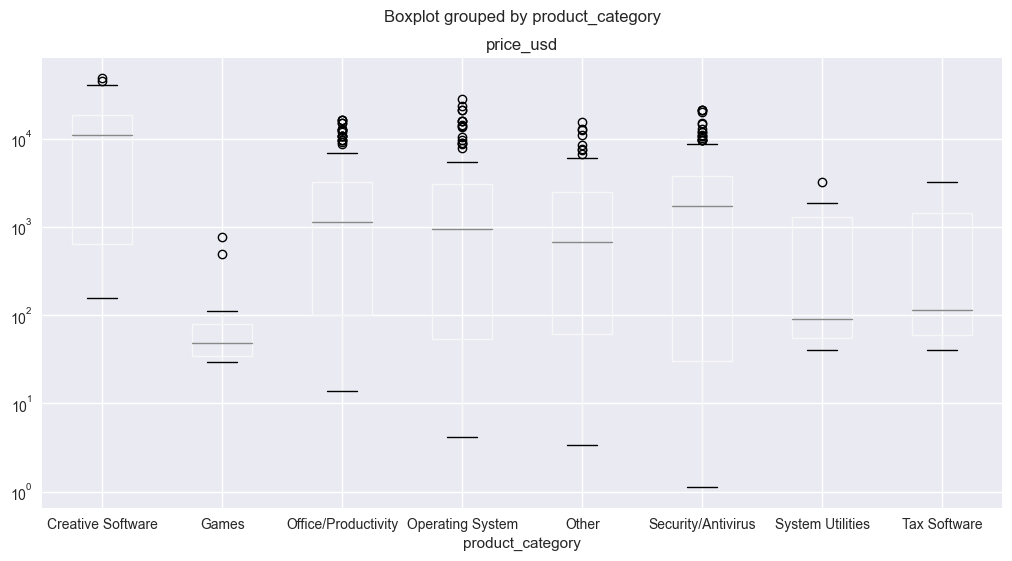

In [12]:
# Price distribution by category
import matplotlib.pyplot as plt
df_clean.boxplot(column='price_usd', by='product_category', figsize=(12,6))
plt.yscale('log')  # Log scale for better visualization
plt.show()

In [13]:
# Popularity by country
country_popularity = df_clean.groupby('country')['product_num_ratings'].mean().sort_values(ascending=False)
print(country_popularity)

country
DE    3684.99000
IN    3421.00000
US    2727.30303
IT     549.82000
JP     501.87000
MX     430.65000
FR     401.50000
AU     389.78000
CA     362.82000
ES     276.12000
Name: product_num_ratings, dtype: float64


1.  Germany (DE)    3,685 reviews  👑  (15x more than Spain!)
2.  India (IN)      3,421 reviews  📈  (Strong software market)
3.  USA (US)        2,727 reviews  🇺🇸  (Massive but diverse market)
4.  Italy (IT)        550 reviews  📊
5.  Japan (JP)        502 reviews  🎮
6.  Mexico (MX)       431 reviews  🌎
7.  France (FR)       402 reviews  🇫🇷
8.  Australia (AU)    390 reviews  🦘
9.  Canada (CA)       363 reviews  🍁
10. Spain (ES)        276 reviews  🇪🇸

In [14]:
# Relationship between price and ratings
correlation = df_clean[['price_usd', 'product_star_rating', 'product_num_ratings']].corr()
print(correlation)

                     price_usd  product_star_rating  product_num_ratings
price_usd             1.000000            -0.050719            -0.073281
product_star_rating  -0.050719             1.000000             0.124588
product_num_ratings  -0.073281             0.124588             1.000000


Relationship	Correlation	Interpretation
1. Price vs Ratings	-0.05	Virtually no relationship - Higher price doesn't mean better or worse ratings
2.  Price vs Reviews	-0.07	Very weak negative - Slightly more reviews for cheaper products
3. Ratings vs Reviews	+0.12	Weak positive - Products with more reviews tend to have slightly higher ratings


In [15]:
df_clean.to_csv('amazon_software_cleaned.csv', index=False)
print("Cleaned data exported for visualization and modeling")

Cleaned data exported for visualization and modeling
